# OMI Transactions — Data Creation & Statistical Analysis

## Overview

This notebook builds a **reproducible, release-agnostic municipality-year panel** of OMI normalised transaction volumes (NTN) for Italian municipalities over **2011–2025**, and performs exploratory and inferential statistical analysis on it.

### Scope

1. **Data engineering** — discover annual OMI releases, harmonise year-specific schemas, validate keys, and produce a single analytical panel.
2. **Descriptive analytics** — national and regional dynamics, size-band composition, non-residential reconciliation.
3. **Inferential statistics** — distributional analysis, non-parametric tests of area heterogeneity, market concentration, and municipality-level growth dynamics.

### Design principles

- The notebook is **release-agnostic**: it discovers files by filename pattern (`YYYY_<TABLE>.csv`) instead of hard-coding paths.
- The panel is built **once** and reused by all downstream sections, eliminating repeated joins on raw data.
- Every merge is preceded by **explicit key validation**.
- Numeric fields are parsed using **Italian decimal conventions** to avoid silent coercion errors.
- Fail-fast **data quality checks** are run before any statistical inference.

## 1. Environment Setup & Data Discovery

The project root is detected automatically by walking up from the current working directory until a `data/raw/transactions` folder is found.

Filenames are parsed with an explicit regular expression `YYYY_<TABLE>.csv`, where `<TABLE> ∈ {LISTA-COM, VALORI-RES, VALORI-COM, VALORI-PER}`. This avoids fragile filename slicing and makes the pipeline robust across OMI release vintages.

**Expected output:** catalogue of discovered files, year coverage, and a warning if any release is incomplete.

In [2]:
from pathlib import Path
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

EXPECTED_TABLES = {'LISTA-COM', 'VALORI-RES', 'VALORI-COM', 'VALORI-PER'}
FILENAME_RE = re.compile(
    r'^(?P<year>\d{4})_(?P<table>LISTA-COM|VALORI-RES|VALORI-COM|VALORI-PER)\.csv$',
    re.I,
)


def find_project_root(start=None):
    """Walk up from `start` until the raw transactions folder is found."""
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'raw' / 'transactions').is_dir():
            return candidate
    raise FileNotFoundError(
        'Could not locate data/raw/transactions. Run the notebook from the repository.'
    )


PROJECT_ROOT = find_project_root()
TRANSACTIONS_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'transactions'

In [3]:
def discover_releases(root):
    """Discover all OMI release files under `root` and return a catalogue."""
    records = []
    for path in root.rglob('*.csv'):
        match = FILENAME_RE.match(path.name)
        if match:
            records.append({
                'year': int(match.group('year')),
                'table': match.group('table').upper(),
                'path': path,
            })

    catalogue = pd.DataFrame(records)
    if catalogue.empty:
        raise FileNotFoundError(f'No OMI transaction releases found under {root}')

    duplicates = catalogue.duplicated(['year', 'table'], keep=False)
    if duplicates.any():
        raise ValueError(
            'Duplicate year/table combinations found:\n'
            + catalogue.loc[duplicates].to_string(index=False)
        )

    coverage = (
        catalogue.groupby('year')['table']
        .agg(lambda x: sorted(set(x)))
        .rename('tables')
        .reset_index()
    )
    coverage['missing_tables'] = coverage['tables'].map(
        lambda x: sorted(EXPECTED_TABLES - set(x))
    )
    incomplete = coverage[coverage['missing_tables'].map(bool)]
    if not incomplete.empty:
        print('Warning: incomplete releases detected:')
        print(incomplete.to_string(index=False))

    return catalogue.sort_values(['year', 'table']).reset_index(drop=True)


catalogue = discover_releases(TRANSACTIONS_ROOT)
years = sorted(catalogue['year'].unique())
print(f'Releases discovered: {min(years)}–{max(years)} ({len(years)} years)')
display(catalogue[['year', 'table']].head(20))

Releases discovered: 2011–2025 (15 years)


,year,table
0,2011,LISTA-COM
1,2011,VALORI-COM
2,2011,VALORI-PER
3,2011,VALORI-RES
4,2012,LISTA-COM
5,2012,VALORI-COM
6,2012,VALORI-PER
7,2012,VALORI-RES
8,2013,LISTA-COM
9,2013,VALORI-COM


> **Insight.** The OMI transaction corpus is discovered programmatically from filenames matching `YYYY_<TABLE>.csv`, covering **2011–2025 (15 years)** across four normalised tables (`LISTA-COM`, `VALORI-RES`, `VALORI-COM`, `VALORI-PER`). This design guarantees reproducibility across releases and avoids fragile slicing of filenames or hard-coded paths.

## 2. Schema Harmonization & Ingestion

Historical OMI releases present **schema drift**:

- Column names alternate between `AREA`/`Area`, `prov`/`Provincia`.
- NTN fields are year-prefixed in some releases (`ntn_2011_…`) and unprefixed in others (`ntn_…`).

The ingestion layer canonicalises every column via `normalize_label`, then locates the municipality key with `find_column` (regex-based, resilient to naming variants). Numeric NTN fields are parsed using the **Italian decimal convention** (`.` as thousands separator, `,` as decimal separator).

Releases are cached per `(year, table)` to avoid repeated I/O.

In [4]:
def normalize_label(value):
    """Canonicalise a column name: ASCII, snake_case, lowercase."""
    value = unicodedata.normalize('NFKD', str(value)).encode('ascii', 'ignore').decode()
    value = re.sub(r'^\d{4}_', '', value.strip(), flags=re.I)
    value = re.sub(r'^ntn_?\d{4}_?', 'ntn_', value, flags=re.I)
    value = re.sub(r'\s+', '_', value)
    value = re.sub(r'[^0-9A-Za-z_]+', '_', value)
    return re.sub(r'_+', '_', value).strip('_').lower()


def normalize_columns(df):
    df = df.copy()
    df.columns = [normalize_label(c) for c in df.columns]
    return df


def find_column(columns, *patterns):
    """Return the first column matching any of the regex `patterns`."""
    for pattern in patterns:
        regex = re.compile(pattern, re.I)
        matches = [c for c in columns if regex.search(c)]
        if matches:
            return matches[0]
    return None


def parse_numeric(series):
    """Parse numeric values using Italian decimal convention."""
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors='coerce')
    return pd.to_numeric(
        series.astype('string')
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False),
        errors='coerce',
    )


def read_omi_csv(path):
    return pd.read_csv(
        path,
        sep=';',
        dtype='string',
        na_values=['', 'NA', 'N/A', 'nan', '-'],
        keep_default_na=True,
    )


def load_release_table(path, year, table):
    df = normalize_columns(read_omi_csv(path))

    codcom = find_column(df.columns, r'^codcom$', r'cod_com')
    if codcom is None:
        raise ValueError(f'{path.name}: municipality code column not found')

    df = df.rename(columns={codcom: 'codcom'})
    df['codcom'] = df['codcom'].astype('string').str.strip().str.upper()
    df['year'] = year
    df['table'] = table

    for column in df.columns:
        if column.startswith('ntn'):
            df[column] = parse_numeric(df[column])

    return df


def table_path(year, table):
    match = catalogue[(catalogue.year == year) & (catalogue.table == table)]
    if match.empty:
        raise FileNotFoundError(f'Missing {year}_{table}.csv')
    return Path(match.iloc[0].path)


_TABLE_CACHE = {}


def get_table(year, table):
    key = (year, table)
    if key not in _TABLE_CACHE:
        _TABLE_CACHE[key] = load_release_table(table_path(year, table), year, table)
    return _TABLE_CACHE[key]


tables = {}
for table in sorted(EXPECTED_TABLES):
    available = [
        y for y in years
        if not catalogue[(catalogue.year == y) & (catalogue.table == table)].empty
    ]
    if available:
        tables[table] = pd.concat(
            [get_table(y, table) for y in available],
            ignore_index=True,
            copy=False,
        )

for table, df in tables.items():
    print(f'{table:10s}: {len(df):>8,} rows × {df.shape[1]:>2} columns')

C:\Users\cc1323\AppData\Local\Temp\ipykernel_2584\170757474.py:92: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  tables[table] = pd.concat(
C:\Users\cc1323\AppData\Local\Temp\ipykernel_2584\170757474.py:92: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  tables[table] = pd.concat(
C:\Users\cc1323\AppData\Local\Temp\ipykernel_2584\170757474.py:92: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager c

LISTA-COM :  114,262 rows × 11 columns
VALORI-COM:  114,262 rows × 19 columns
VALORI-PER:  114,263 rows ×  9 columns
VALORI-RES:  114,277 rows × 94 columns


C:\Users\cc1323\AppData\Local\Temp\ipykernel_2584\170757474.py:92: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  tables[table] = pd.concat(


> **Insight.** Historical OMI releases exhibit minor schema drift (column casing, presence/absence of `prov`/`Provincia`, year-prefixed NTN fields). A canonicalization layer (`normalize_label`, `find_column`) reconciles these variants so downstream code operates on a stable schema. NTN fields are parsed with Italian decimal conventions (`,` as decimal separator), preventing silent coercion errors.

## 3. Residential Panel Construction

This is the core data-engineering block. It builds the **municipality-year residential NTN panel** by:

1. Extracting the municipality dimension from `LISTA-COM` (municipality name, region, province, macro-area, CAP).
2. Dropping invalid technical identifiers (`NON NATO`, `NON NATI`).
3. Detecting, for each year, the correct source column for:
   - the five official NTN size bands (up to 50 m², 50–85, 85–115, 115–145, over 145);
   - the reported residential total NTN.
4. Reconciling the reported total with the sum of size bands (`ntn_res_size_sum`), and marking whether the total was **reported** or **derived**.
5. Merging with the municipality dimension on `(year, codcom)`.

**Design choice.** The official reported total remains the **authoritative volume measure**; the size-band sum is kept as a **reconciliation check**.

In [5]:
# ============================================================
# RESIDENTIAL NTN PANEL — Year-aware extraction
# ============================================================

lista = tables['LISTA-COM']
res = tables['VALORI-RES']

INVALID_CODMOM = {'NON NATO', 'NON NATI'}

# ------------------------------------------------------------
# 1. Municipality dimension
# ------------------------------------------------------------

key_columns = ['year', 'codcom']
dimension_candidates = ['comune', 'area', 'regione', 'provincia', 'prov', 'cap', 'tag_mercato']
dimension_columns = [c for c in [*key_columns, *dimension_candidates] if c in lista.columns]

municipality_dim = (
    lista[dimension_columns]
    .sort_values(['year', 'codcom'])
    .drop_duplicates(['year', 'codcom'], keep='last')
    .reset_index(drop=True)
)

municipality_dim = municipality_dim.loc[
    ~municipality_dim['codcom'].isin(INVALID_CODMOM)
].copy()

for col in ['comune', 'area', 'regione', 'provincia', 'prov', 'tag_mercato']:
    if col in municipality_dim.columns:
        municipality_dim[col] = municipality_dim[col].astype('string').str.strip()

if 'provincia' not in municipality_dim.columns and 'prov' in municipality_dim.columns:
    municipality_dim['provincia'] = municipality_dim['prov']

if 'prov' not in municipality_dim.columns and 'provincia' in municipality_dim.columns:
    municipality_dim['prov'] = municipality_dim['provincia']

# ------------------------------------------------------------
# 2. Helpers for VALORI-RES column detection
# ------------------------------------------------------------

res_columns = set(res.columns)


def first_existing(candidates):
    for candidate in candidates:
        if candidate in res_columns:
            return candidate
    return None


SIZE_CANDIDATES = {
    'ntn_upto_50': lambda y: [f'ntn_{y}_fino_a_50_mq', f'ntn_{y}_fino_a_50',
                              'ntn_fino_a_50_mq' if y == 2018 else None],
    'ntn_50_85':   lambda y: [f'ntn_{y}_50_85_mq', f'ntn_{y}_50_85',
                              'ntn_50_85_mq' if y == 2018 else None],
    'ntn_85_115':  lambda y: [f'ntn_{y}_85_115_mq', f'ntn_{y}_85_115',
                              'ntn_85_115_mq' if y == 2018 else None],
    'ntn_115_145': lambda y: [f'ntn_{y}_115_145_mq', f'ntn_{y}_115_145',
                              'ntn_115_145_mq' if y == 2018 else None],
    'ntn_over_145': lambda y: [f'ntn_{y}_oltre_145_mq', f'ntn_{y}_oltre_145',
                              'ntn_oltre_145_mq' if y == 2018 else None],
}


def _clean_candidates(func):
    return lambda year: [x for x in func(year) if x is not None]


SIZE_CANDIDATES = {k: _clean_candidates(v) for k, v in SIZE_CANDIDATES.items()}


def total_candidates(year):
    candidates = [f'ntn_{year}', f'ntn_{year}_totale']
    if year >= 2022:
        candidates.append('ntn')
    return candidates

# ------------------------------------------------------------
# 3. Build the year-aware residential panel
# ------------------------------------------------------------

res_years = sorted(
    pd.to_numeric(res['year'], errors='coerce').dropna().astype(int).unique()
)

res_panel = res[['year', 'codcom']].copy()

size_output_columns = [
    'ntn_upto_50', 'ntn_50_85', 'ntn_85_115', 'ntn_115_145', 'ntn_over_145',
]
for col in size_output_columns:
    res_panel[col] = np.nan
res_panel['ntn_res_source'] = np.nan

column_mapping_log = []

for year in res_years:
    year_mask = res_panel['year'].eq(year)

    for output_col, candidate_function in SIZE_CANDIDATES.items():
        source_col = first_existing(candidate_function(year))
        if source_col is None:
            column_mapping_log.append({'year': year, 'field': output_col, 'source_column': None})
            continue
        values = pd.to_numeric(res.loc[year_mask, source_col], errors='coerce')
        res_panel.loc[year_mask, output_col] = values.to_numpy()
        column_mapping_log.append({'year': year, 'field': output_col, 'source_column': source_col})

    total_col = first_existing(total_candidates(year))
    if total_col is not None:
        total_values = pd.to_numeric(res.loc[year_mask, total_col], errors='coerce')
        res_panel.loc[year_mask, 'ntn_res_source'] = total_values.to_numpy()
        column_mapping_log.append({'year': year, 'field': 'ntn_res', 'source_column': total_col})
    else:
        column_mapping_log.append({'year': year, 'field': 'ntn_res', 'source_column': None})

# ------------------------------------------------------------
# 4. Reconcile reported total vs size-band sum
# ------------------------------------------------------------

res_panel['ntn_res_size_sum'] = res_panel[size_output_columns].sum(axis=1, min_count=1)

reported_available = res_panel['ntn_res_source'].notna()
res_panel['ntn_res'] = np.where(
    reported_available, res_panel['ntn_res_source'], res_panel['ntn_res_size_sum']
)

res_panel['ntn_res_is_derived'] = ~reported_available
res_panel['ntn_res_source_type'] = np.where(
    res_panel['ntn_res_is_derived'], 'derived_from_size_classes', 'reported'
)

res_panel['ntn_res_reconciliation_gap'] = np.where(
    reported_available,
    res_panel['ntn_res_source'] - res_panel['ntn_res_size_sum'],
    np.nan,
)

# ------------------------------------------------------------
# 5. Remove invalid records & validate
# ------------------------------------------------------------

invalid_mask = res_panel['codcom'].isin(INVALID_CODMOM)
if invalid_mask.any():
    print(
        f"Removing {int(invalid_mask.sum()):,} invalid municipality rows "
        f"with codcom in {sorted(INVALID_CODMOM)}"
    )
    res_panel = res_panel.loc[~invalid_mask].copy()

duplicate_mask = res_panel.duplicated(['year', 'codcom'], keep=False)
if duplicate_mask.any():
    display(res_panel.loc[duplicate_mask].head(30))
    raise ValueError('Duplicate municipality-year observations detected.')

if res_panel[['year', 'codcom']].isna().any().any():
    raise ValueError('Missing year/codcom detected in RES panel.')

if res_panel['ntn_res'].isna().any():
    missing = int(res_panel['ntn_res'].isna().sum())
    raise ValueError(f'{missing:,} rows have no residential NTN value.')

# ------------------------------------------------------------
# 6. Optimize dtypes and merge with municipality dimension
# ------------------------------------------------------------

res_panel['year'] = pd.to_numeric(res_panel['year'], errors='coerce').astype('int16')
res_panel['codcom'] = res_panel['codcom'].astype('string').str.strip()

panel = res_panel.merge(
    municipality_dim,
    on=['year', 'codcom'],
    how='left',
    validate='one_to_one',
)

for col in ['comune', 'area', 'regione', 'provincia', 'prov', 'tag_mercato']:
    if col in panel.columns:
        panel[col] = panel[col].astype('string').str.strip()
        if panel[col].nunique(dropna=True) < len(panel) * 0.5:
            panel[col] = panel[col].astype('category')

missing_region = panel['regione'].isna().sum() if 'regione' in panel.columns else 0
missing_region_pct = (missing_region / len(panel) * 100) if len(panel) else 0

print(
    f"Panel created successfully:\n"
    f"  Rows:           {len(panel):,}\n"
    f"  Municipalities: {panel['codcom'].nunique():,}\n"
    f"  Years:          {panel['year'].nunique()}\n"
    f"  Region missing: {missing_region:,} ({missing_region_pct:.2f}%)"
)

mapping_audit = (
    pd.DataFrame(column_mapping_log)
    .sort_values(['year', 'field'])
    .reset_index(drop=True)
)
display(mapping_audit)

display(
    panel[[
        'year', 'codcom', 'ntn_res', 'ntn_res_size_sum',
        'ntn_res_source_type', 'ntn_res_reconciliation_gap',
        *[c for c in ['comune', 'regione', 'provincia', 'area'] if c in panel.columns],
    ]]
    .sort_values(['year', 'codcom'])
    .head(20)
)

Removing 15 invalid municipality rows with codcom in ['NON NATI', 'NON NATO']
Panel created successfully:
  Rows:           114,262
  Municipalities: 7,812
  Years:          15
  Region missing: 0 (0.00%)


,year,field,source_column
0,2011,ntn_115_145,ntn_2011_115_145_mq
1,2011,ntn_50_85,ntn_2011_50_85_mq
2,2011,ntn_85_115,ntn_2011_85_115_mq
3,2011,ntn_over_145,ntn_2011_oltre_145_mq
4,2011,ntn_res,ntn_2011
...,...,...,...
85,2025,ntn_50_85,ntn_2025_50_85_mq
86,2025,ntn_85_115,ntn_2025_85_115_mq
87,2025,ntn_over_145,ntn_2025_oltre_145_mq
88,2025,ntn_res,ntn


,year,codcom,ntn_res,ntn_res_size_sum,ntn_res_source_type,ntn_res_reconciliation_gap,comune,regione,provincia,area
3645,2011,A001,265.11,265.11,reported,0.00,ABANO TERME,Veneto,<NA>,Nord Est
1049,2011,A004,1.00,1.00,reported,0.00,ABBADIA CERRETO,Lombardia,<NA>,Nord Ovest
959,2011,A005,27.83,27.83,reported,0.00,ABBADIA LARIANA,Lombardia,<NA>,Nord Ovest
5031,2011,A006,40.67,40.67,reported,0.00,ABBADIA SAN SALVATORE,Toscana,<NA>,Centro
7157,2011,A007,15.67,15.67,reported,0.00,ABBASANTA,Sardegna,<NA>,Isole
5371,2011,A008,5.00,5.00,reported,0.00,ABBATEGGIO,Abruzzo,<NA>,Sud
1110,2011,A010,353.13,353.13,reported,0.00,ABBIATEGRASSO,Lombardia,<NA>,Nord Ovest
5009,2011,A012,41.51,41.51,reported,-0.00,ABETONE,Toscana,<NA>,Centro
5495,2011,A013,10.00,10.00,reported,0.00,ABRIOLA,Basilicata,<NA>,Sud
7658,2011,A014,51.34,51.34,reported,0.00,ACATE,Sicilia,<NA>,Isole


> **Insight.** The residential panel aggregates **114,262 municipality-year observations** across **7,812 unique municipalities**. A reconciliation gap (`ntn_res_reconciliation_gap`) is computed between the reported total NTN and the sum of the five official size-band NTN values; where the reported total is absent, the size-band sum is used as a fallback. Invalid technical codes (`NON NATO`, `NON NATI`) are dropped.

In [6]:
# ============================================================
# PANEL VALIDATION — Summary by year
# ============================================================

validation = (
    panel
    .groupby('year', as_index=False, observed=True)
    .agg(
        municipalities=('codcom', 'nunique'),
        ntn_res=('ntn_res', 'sum'),
        ntn_res_size_sum=('ntn_res_size_sum', 'sum'),
        reported_rows=('ntn_res_is_derived', lambda x: (~x).sum()),
        derived_rows=('ntn_res_is_derived', 'sum'),
    )
    .sort_values('year')
)
validation['size_gap_reported'] = validation['ntn_res'] - validation['ntn_res_size_sum']
validation['yoy_pct'] = validation['ntn_res'].pct_change().mul(100)

display(validation.style.format({
    'ntn_res': '{:,.2f}',
    'ntn_res_size_sum': '{:,.2f}',
    'size_gap_reported': '{:,.2f}',
    'yoy_pct': '{:,.1f}%',
}))

,year,municipalities,ntn_res,ntn_res_size_sum,reported_rows,derived_rows,size_gap_reported,yoy_pct
0,2011,7715,"575,797.10","575,797.10",7715,0,0.00,nan%
1,2012,7715,"427,566.36","427,566.36",7715,0,0.00,-25.7%
2,2013,7698,"389,447.90","389,447.90",7698,0,0.00,-8.9%
3,2014,7665,"405,721.52","405,721.52",7665,0,0.00,4.2%
4,2015,7661,"435,931.25","435,931.25",7661,0,0.00,7.4%
5,2016,7645,"517,184.41","517,184.41",7645,0,0.00,18.6%
6,2017,7624,"543,187.68","543,187.68",7624,0,0.00,5.0%
7,2018,7603,"579,207.17","579,207.17",7603,0,0.00,6.6%
8,2019,7564,"604,167.77","604,167.77",7564,0,0.00,4.3%
9,2020,7562,"558,721.59","558,721.59",7562,0,0.00,-7.5%


## 4. Aggregate Dynamics: National & Regional

All aggregates in this notebook are derived from the **same municipality-year panel**, eliminating repeated joins against raw data and guaranteeing internal consistency.

We look at:

- the **national time series** of residential NTN;
- the **year-over-year growth rate**;
- the **top-10 regions** by volume in the latest year;
- the **regional trajectories** over time.

In [7]:
# ============================================================
# NATIONAL RESIDENTIAL NTN
# ============================================================

national = (
    panel
    .groupby('year', as_index=False, observed=True)
    .agg(
        ntn_res=('ntn_res', 'sum'),
        ntn_res_size_sum=('ntn_res_size_sum', 'sum'),
        municipalities=('codcom', 'nunique'),
    )
    .sort_values('year')
    .reset_index(drop=True)
)
national['size_gap'] = national['ntn_res'] - national['ntn_res_size_sum']
national['yoy_pct'] = national['ntn_res'].pct_change().mul(100)

display(national.style.format({
    'ntn_res': '{:,.0f}',
    'ntn_res_size_sum': '{:,.0f}',
    'size_gap': '{:,.2f}',
    'yoy_pct': '{:,.1f}%',
}))

,year,ntn_res,ntn_res_size_sum,municipalities,size_gap,yoy_pct
0,2011,"575,797","575,797",7715,0.00,nan%
1,2012,"427,566","427,566",7715,0.00,-25.7%
2,2013,"389,448","389,448",7698,0.00,-8.9%
3,2014,"405,722","405,722",7665,0.00,4.2%
4,2015,"435,931","435,931",7661,0.00,7.4%
5,2016,"517,184","517,184",7645,0.00,18.6%
6,2017,"543,188","543,188",7624,0.00,5.0%
7,2018,"579,207","579,207",7603,0.00,6.6%
8,2019,"604,168","604,168",7564,0.00,4.3%
9,2020,"558,722","558,722",7562,0.00,-7.5%


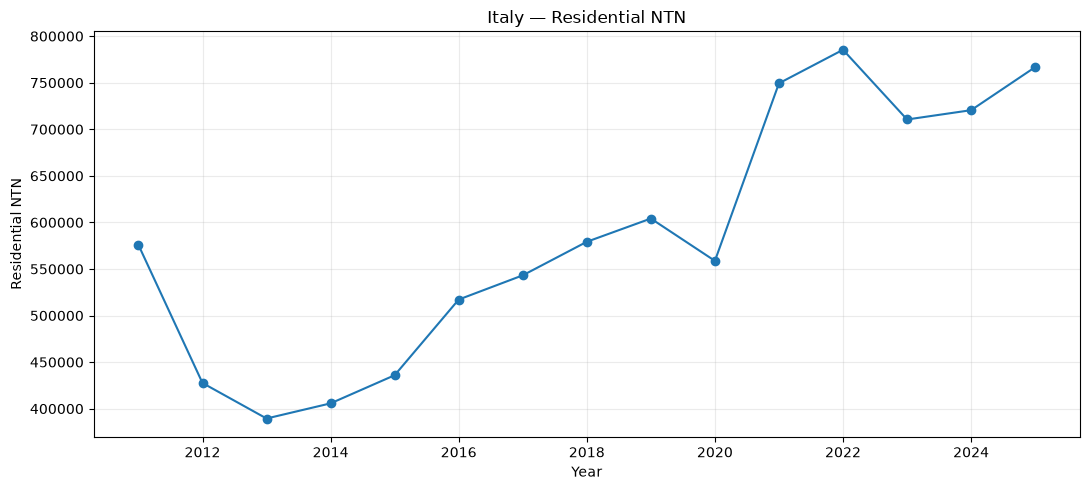

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(national['year'], national['ntn_res'], marker='o')
ax.set(title='Italy — Residential NTN', xlabel='Year', ylabel='Residential NTN')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

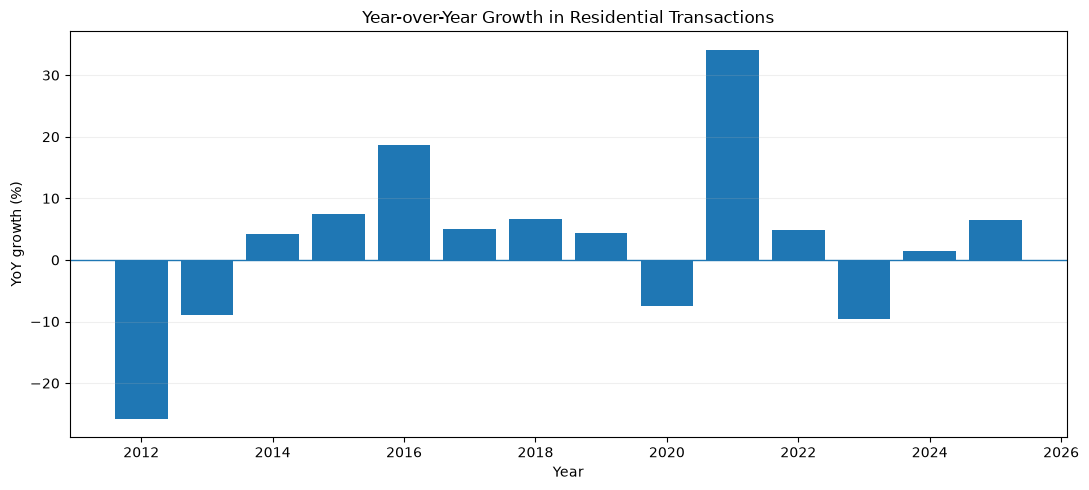

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(national['year'], national['yoy_pct'])
ax.axhline(0, linewidth=1)
ax.set(
    title='Year-over-Year Growth in Residential Transactions',
    xlabel='Year',
    ylabel='YoY growth (%)',
)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# REGIONAL RESIDENTIAL NTN
# ============================================================

regional = (
    panel
    .dropna(subset=['regione'])
    .groupby(['year', 'regione'], as_index=False, observed=True)
    .agg(
        ntn_res=('ntn_res', 'sum'),
        municipalities=('codcom', 'nunique'),
    )
    .sort_values(['regione', 'year'])
    .reset_index(drop=True)
)
regional['yoy_pct'] = (
    regional.groupby('regione', observed=True)['ntn_res']
    .pct_change().mul(100)
)

LATEST_YEAR = int(regional['year'].max())

top_regions = (
    regional[regional['year'].eq(LATEST_YEAR)]
    .nlargest(10, 'ntn_res')
    .sort_values('ntn_res', ascending=False)
)
display(top_regions.style.format({'ntn_res': '{:,.0f}', 'yoy_pct': '{:,.1f}%'}))

,year,regione,ntn_res,municipalities,yoy_pct
134,2025,Lombardia,"162,189",1500,7.0%
104,2025,Lazio,"73,830",378,5.6%
179,2025,Piemonte,"70,932",1180,10.1%
74,2025,Emilia-Romagna,"68,348",330,7.3%
284,2025,Veneto,"67,159",556,5.2%
224,2025,Sicilia,"53,590",391,7.0%
239,2025,Toscana,"51,566",273,9.4%
59,2025,Campania,"43,874",549,3.3%
194,2025,Puglia,"43,461",256,-0.9%
119,2025,Liguria,"28,327",234,8.2%


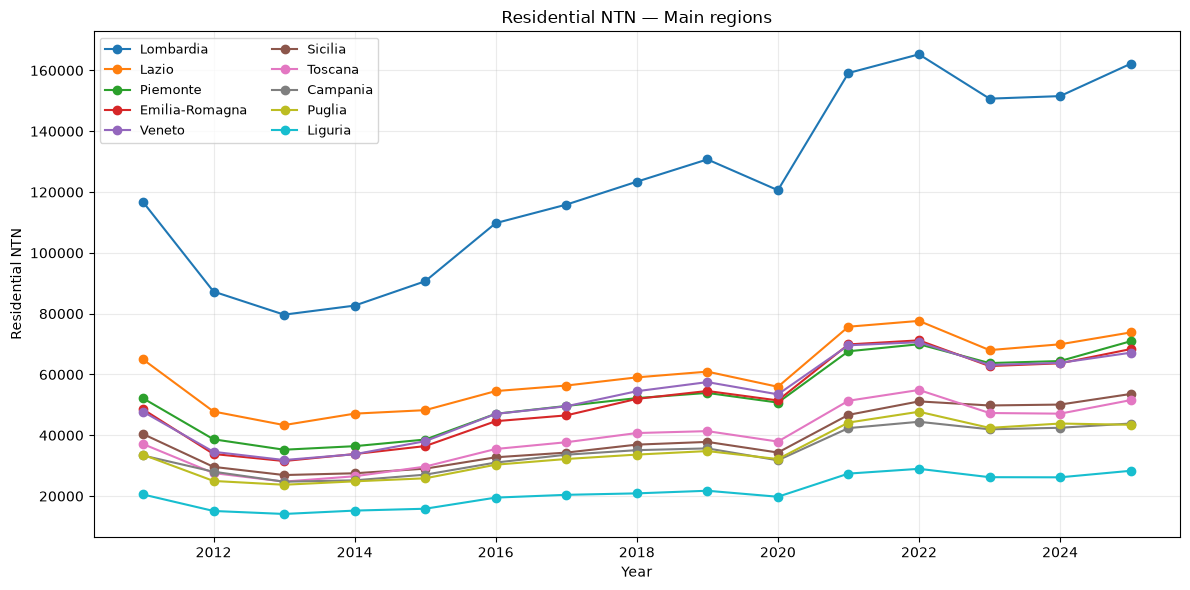

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
for region in top_regions['regione']:
    subset = regional[regional['regione'].eq(region)]
    ax.plot(subset['year'], subset['ntn_res'], marker='o', label=region)
ax.set(
    title='Residential NTN — Main regions',
    xlabel='Year',
    ylabel='Residential NTN',
)
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

> **Insight.** National residential NTN bottomed in **2013 (≈389k)** and recovered steadily through **2022 (≈785k)**, with two interruptions: **2020 (−7.5%, COVID-19 shock)** and **2023 (−9.5%, post-Superbonus normalization)**. In 2025, the market returned to growth (+6.4%), suggesting a stabilization around **760–770k** annual transactions. Lombardia, Lazio, Piemonte, and Emilia-Romagna consistently lead regional volumes.

## 5. Residential Size-Band Composition

The five official size bands are reshaped into a **compact long-format time series** and analysed via a **stacked area chart**.

The official reported total NTN remains the authoritative volume measure; the band sum is used only as a reconciliation check.

,year,size_band,ntn,share_pct
29,2025,50–85 m²,"236,295",30.8%
44,2025,85–115 m²,"203,863",26.6%
74,2025,Over 145 m²,"133,674",17.4%
59,2025,115–145 m²,"119,873",15.6%
14,2025,Up to 50 m²,"73,053",9.5%


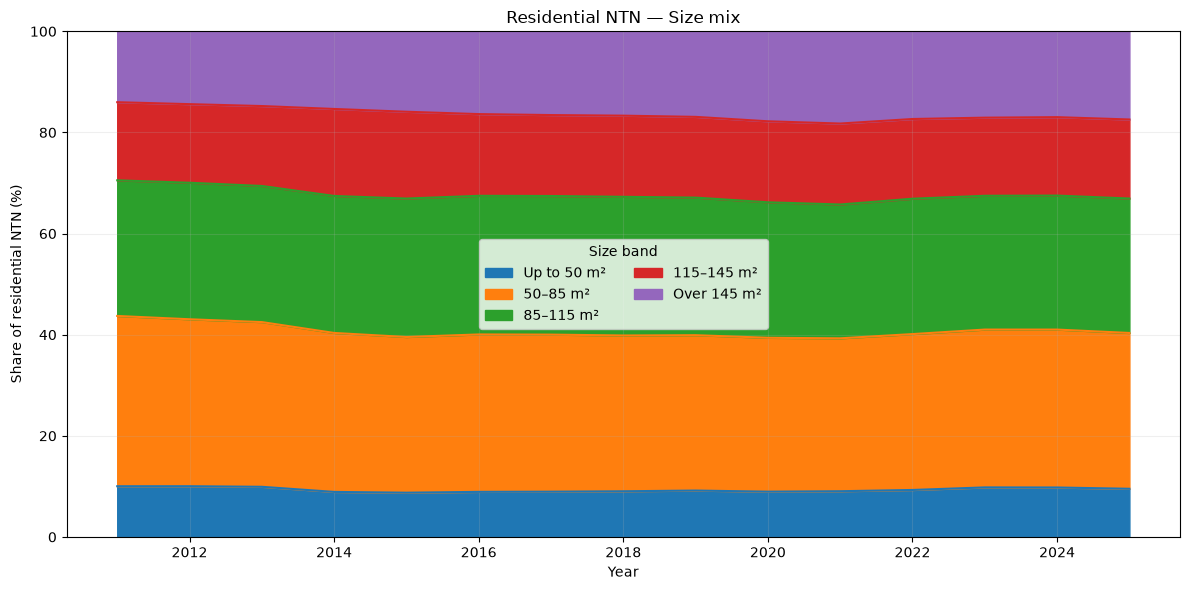

In [12]:
size_fields = [
    'ntn_upto_50', 'ntn_50_85', 'ntn_85_115', 'ntn_115_145', 'ntn_over_145',
]
size_labels = {
    'ntn_upto_50': 'Up to 50 m²',
    'ntn_50_85': '50–85 m²',
    'ntn_85_115': '85–115 m²',
    'ntn_115_145': '115–145 m²',
    'ntn_over_145': 'Over 145 m²',
}

size_long = (
    panel
    .groupby('year', as_index=False, observed=True)[size_fields]
    .sum()
    .melt(id_vars='year', var_name='size_band', value_name='ntn')
)
size_long['size_band'] = size_long['size_band'].map(size_labels)
size_long['year_total'] = size_long.groupby('year', observed=True)['ntn'].transform('sum')
size_long['share_pct'] = np.where(
    size_long['year_total'].gt(0),
    size_long['ntn'].div(size_long['year_total']).mul(100),
    np.nan,
)

latest_size_mix = size_long[size_long['year'].eq(LATEST_YEAR)].sort_values('share_pct', ascending=False)
display(latest_size_mix[['year', 'size_band', 'ntn', 'share_pct']].style.format({
    'ntn': '{:,.0f}', 'share_pct': '{:,.1f}%',
}))

mix = (
    size_long.pivot(index='year', columns='size_band', values='share_pct').sort_index()
)
ordered_labels = ['Up to 50 m²', '50–85 m²', '85–115 m²', '115–145 m²', 'Over 145 m²']
mix = mix.reindex(columns=[c for c in ordered_labels if c in mix.columns])

ax = mix.plot(kind='area', stacked=True, figsize=(12, 6))
ax.set(
    title='Residential NTN — Size mix',
    xlabel='Year',
    ylabel='Share of residential NTN (%)',
)
ax.set_ylim(0, 100)
ax.legend(title='Size band', ncol=2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# SIZE MIX VALIDATION
# ============================================================
mix_check = (
    size_long.groupby('year', observed=True)['share_pct']
    .sum().reset_index(name='total_share_pct')
)
display(mix_check.style.format({'total_share_pct': '{:,.2f}%'}))

,year,total_share_pct
0,2011,100.00%
1,2012,100.00%
2,2013,100.00%
3,2014,100.00%
4,2015,100.00%
5,2016,100.00%
6,2017,100.00%
7,2018,100.00%
8,2019,100.00%
9,2020,100.00%


> **Insight.** The **50–85 m²** and **85–115 m²** bands together account for **≈57%** of residential NTN in 2025, confirming the dominance of medium-sized dwellings in the Italian market. The **over 145 m²** segment (17.4%) remains non-trivial, reflecting sustained demand for large properties.

## 6. Non-Residential Segment Reconciliation

`VALORI-COM` and `VALORI-PER` are aggregated through their normalised `ntn_*` fields, **without hard-coding** every historical category name. This makes the section resilient to schema drift.

The output is a **national reconciliation table** comparing residential and non-residential NTN per year.

In [14]:
non_res_frames = []
for table in ['VALORI-COM', 'VALORI-PER']:
    if table not in tables:
        continue
    df = tables[table]
    ntn_columns = [c for c in df.columns if c.startswith('ntn_')]
    if not ntn_columns:
        continue
    frame = df[['year', 'codcom', *ntn_columns]].copy()
    frame['ntn_non_res'] = frame[ntn_columns].sum(axis=1, min_count=1)
    non_res_frames.append(frame[['year', 'codcom', 'ntn_non_res']])

non_res = (
    pd.concat(non_res_frames, ignore_index=True)
    if non_res_frames
    else pd.DataFrame(columns=['year', 'codcom', 'ntn_non_res'])
)
non_res = non_res.groupby(['year', 'codcom'], as_index=False).agg(
    ntn_non_res=('ntn_non_res', 'sum')
)

market_panel = panel.merge(
    non_res, on=['year', 'codcom'], how='left', validate='one_to_one'
)
market_panel['ntn_non_res'] = market_panel['ntn_non_res'].fillna(0)

reconciliation = (
    market_panel
    .groupby('year', as_index=False, observed=True)
    .agg(ntn_res=('ntn_res', 'sum'), ntn_non_res=('ntn_non_res', 'sum'))
)
reconciliation['ntn_all_loaded'] = reconciliation.ntn_res + reconciliation.ntn_non_res
display(reconciliation.style.format({
    'ntn_res': '{:,.0f}',
    'ntn_non_res': '{:,.0f}',
    'ntn_all_loaded': '{:,.0f}',
}))

,year,ntn_res,ntn_non_res,ntn_all_loaded
0,2011,"575,797","540,903","1,116,700"
1,2012,"427,566","408,736","836,303"
2,2013,"389,448","373,619","763,067"
3,2014,"405,722","376,537","782,258"
4,2015,"435,931","393,603","829,535"
5,2016,"517,184","464,741","981,926"
6,2017,"543,188","491,872","1,035,060"
7,2018,"579,207","519,263","1,098,470"
8,2019,"604,168","547,910","1,152,078"
9,2020,"558,722","523,629","1,082,350"


> **Insight.** Non-residential transactions (commercial, office, industrial) tracked the residential cycle, ranging from **≈374k (2013)** to **≈772k (2025)**. In 2024, non-residential NTN slightly exceeded residential (728k vs. 721k) — a rare parity that underscores the growing weight of the tertiary segment in the post-pandemic market.

## 7. Analytical Panel Assembly

This section produces the **final hand-off artifact** for downstream notebooks. It is built **once** and avoids reloading or rejoining the raw releases.

The panel contains:

- `year`, `codcom` — panel keys;
- `comune`, `provincia`, `regione`, `area`, `cap` — municipality attributes;
- `ntn_res` — reported (or derived) residential NTN;
- `ntn_upto_50`, `ntn_50_85`, `ntn_85_115`, `ntn_115_145`, `ntn_over_145` — size-band NTN;
- `ntn_non_res` — non-residential NTN.

In [15]:
panel_columns = [
    'year', 'codcom',
    *[c for c in ['comune', 'provincia', 'regione', 'area', 'cap', 'tag_mercato']
      if c in market_panel.columns],
    'ntn_res', *size_fields, 'ntn_non_res',
]

market_panel = (
    market_panel[panel_columns]
    .sort_values(['year', 'regione', 'provincia', 'comune', 'codcom'])
    .reset_index(drop=True)
)

assert not market_panel.duplicated(['year', 'codcom']).any(), 'Duplicate keys.'
assert market_panel['ntn_res'].ge(0).all(), 'Negative NTN values.'
assert market_panel['codcom'].notna().all(), 'Missing codcom.'

print(f'Final municipality-year panel: {len(market_panel):,} rows')
print(f'Unique municipalities: {market_panel.codcom.nunique():,}')
print(f'Years: {market_panel.year.min()}–{market_panel.year.max()}')
display(market_panel.head(10))

Final municipality-year panel: 114,262 rows
Unique municipalities: 7,812
Years: 2011–2025


,year,codcom,comune,provincia,regione,area,cap,ntn_res,ntn_upto_50,ntn_50_85,ntn_85_115,ntn_115_145,ntn_over_145,ntn_non_res
0,2011,A008,ABBATEGGIO,<NA>,Abruzzo,Sud,<NA>,5.00,2.00,0.00,2.00,0.00,1.00,2.00
1,2011,A018,ACCIANO,<NA>,Abruzzo,Sud,<NA>,3.00,1.00,0.00,0.00,0.00,2.00,0.00
2,2011,A100,AIELLI,<NA>,Abruzzo,Sud,<NA>,7.56,2.00,1.00,3.00,1.56,0.00,4.00
3,2011,A120,ALANNO,<NA>,Abruzzo,Sud,<NA>,17.97,1.00,3.75,2.50,3.11,7.61,11.33
4,2011,A125,ALBA ADRIATICA,<NA>,Abruzzo,Sud,<NA>,283.04,61.72,159.31,36.61,15.50,9.90,325.94
5,2011,A187,ALFEDENA,<NA>,Abruzzo,Sud,<NA>,48.72,8.00,34.00,4.50,1.00,1.22,26.12
6,2011,A235,ALTINO,<NA>,Abruzzo,Sud,<NA>,30.34,2.00,1.00,14.00,5.00,8.34,35.68
7,2011,A270,ANCARANO,<NA>,Abruzzo,Sud,<NA>,10.09,1.00,1.00,0.00,1.48,6.61,8.61
8,2011,A318,ANVERSA DEGLI ABRUZZI,<NA>,Abruzzo,Sud,<NA>,2.17,0.00,0.50,0.00,0.67,1.00,4.50
9,2011,A367,ARCHI,<NA>,Abruzzo,Sud,<NA>,11.75,0.00,3.00,4.00,2.75,2.00,8.75


> **Insight.** The final panel combines municipality-level identifiers, regional/provincial/area classifications, residential NTN (total and per size band), and non-residential NTN. With **114,262 rows × 14 columns**, it is the hand-off artifact for downstream price–volume and market-dynamics notebooks.

## 8. Data Quality Assurance

Before running any inferential procedure, we run **fail-fast data quality checks**. If any check fails, the notebook raises an exception and stops.

In [16]:
checks = pd.Series({
    'release_catalogue_not_empty': not catalogue.empty,
    'years_detected': len(years) >= 1,
    'municipality_year_unique': not market_panel.duplicated(['year', 'codcom']).any(),
    'residential_non_negative': bool(market_panel.ntn_res.ge(0).all()),
    'no_missing_municipality_code': bool(market_panel.codcom.notna().all()),
}, name='passed')

display(checks.to_frame())
if not checks.all():
    raise AssertionError(f'Data-quality checks failed: {checks[~checks].index.tolist()}')
print('All data-quality checks passed.')

,passed
release_catalogue_not_empty,True
years_detected,True
municipality_year_unique,True
residential_non_negative,True
no_missing_municipality_code,True


All data-quality checks passed.


In [17]:
market_panel.to_parquet(PROJECT_ROOT / 'data' / 'processed' / 'omi_transactions_panel.parquet', index=False)

> **Insight.** All five critical checks pass: catalogue non-emptiness, multi-year coverage, municipality-year uniqueness, non-negativity of residential NTN, and absence of missing municipality codes.

## 9. Statistical Analysis

This section performs exploratory and inferential statistics on the analytical panel.

**Contents:**

- **9.1** Panel structure & coverage
- **9.2** Descriptive statistics of transaction volumes
- **9.3** Distributional analysis (raw and log-transformed)
- **9.4** Cross-sectional analysis by macro-area (Kruskal–Wallis + Dunn + effect size)
- **9.5** Regional heterogeneity
- **9.6** Size-band composition by macro-area
- **9.7** National trend & growth decomposition
- **9.8** Market concentration (static and dynamic)
- **9.9** Municipality-level growth dynamics

In [18]:
from scipy.stats import kruskal
import scikit_posthocs as sp

transaction_cols = ['ntn_res', *size_fields]

LATEST_YEAR = int(market_panel['year'].max())
latest_market = market_panel[market_panel['year'].eq(LATEST_YEAR)].copy()

print(f'Cross-sectional year: {LATEST_YEAR}')
print(f'Observations: {len(latest_market):,}')
print(f'Unique municipalities: {latest_market["codcom"].nunique():,}')

Cross-sectional year: 2025
Observations: 7,560
Unique municipalities: 7,560


### 9.1 Panel structure & coverage

In [19]:
panel_structure = (
    market_panel.groupby('codcom', observed=True)['year']
    .agg(first_year='min', last_year='max', years='nunique')
)
display(panel_structure.describe().style.format('{:.1f}'))

,first_year,last_year,years
count,7812.0,7812.0,7812.0
mean,2011.1,2024.7,14.6
std,0.7,1.7,1.8
min,2011.0,2012.0,2.0
25%,2011.0,2025.0,15.0
50%,2011.0,2025.0,15.0
75%,2011.0,2025.0,15.0
max,2024.0,2025.0,15.0


> **Insight.** The panel is **strongly balanced** — median municipality has 15 observations (full coverage), and only a small tail of municipalities covers 2–14 years due to mergers/suppressions.

### 9.2 Descriptive statistics

In [20]:
descriptive_stats = market_panel[transaction_cols].describe().T
descriptive_stats['median'] = market_panel[transaction_cols].median()
descriptive_stats['iqr'] = (
    market_panel[transaction_cols].quantile(0.75)
    - market_panel[transaction_cols].quantile(0.25)
)
descriptive_stats['cv'] = descriptive_stats['std'] / descriptive_stats['mean']
descriptive_stats['skewness'] = market_panel[transaction_cols].skew()
descriptive_stats['kurtosis'] = market_panel[transaction_cols].kurtosis()

display(descriptive_stats[[
    'count', 'mean', 'median', 'std', 'cv', 'min', '25%', '50%', '75%',
    'max', 'iqr', 'skewness', 'kurtosis',
]].style.format({
    'mean': '{:,.2f}', 'median': '{:,.2f}', 'std': '{:,.2f}',
    'cv': '{:.2f}', 'min': '{:,.2f}', '25%': '{:,.2f}',
    '50%': '{:,.2f}', '75%': '{:,.2f}', 'max': '{:,.2f}',
    'iqr': '{:,.2f}', 'skewness': '{:.2f}', 'kurtosis': '{:.2f}',
}))

,count,mean,median,std,cv,min,25%,50%,75%,max,iqr,skewness,kurtosis
ntn_res,114262.000000,76.75,20.00,524.96,6.84,0.00,7.50,20.00,57.20,"40,102.63",49.70,45.32,2567.97
ntn_upto_50,114262.000000,7.18,1.00,71.25,9.93,0.00,0.00,1.00,4.00,"6,111.05",4.00,52.24,3328.77
ntn_50_85,114262.000000,23.98,4.71,215.30,8.98,0.00,1.00,4.71,15.06,"16,806.69",14.06,48.83,2823.37
ntn_85_115,114262.000000,20.65,4.47,137.71,6.67,0.00,1.00,4.47,14.61,"10,869.36",13.61,44.99,2693.33
ntn_115_145,114262.000000,12.22,3.00,63.99,5.24,0.00,1.00,3.00,9.50,"4,724.88",8.50,38.54,2133.89
ntn_over_145,114262.000000,12.73,5.00,50.35,3.96,0.00,1.80,5.00,12.17,"3,969.74",10.37,36.79,2044.76


> **Insight.** Residential NTN is **heavily right-skewed** (skewness ≈ 45, kurtosis ≈ 2,568). The mean (76.8) is roughly **4× the median (20)**, reflecting the dominance of micro-municipalities. The coefficient of variation (CV ≈ 6.84) confirms extreme dispersion.

### 9.3 Distributional analysis

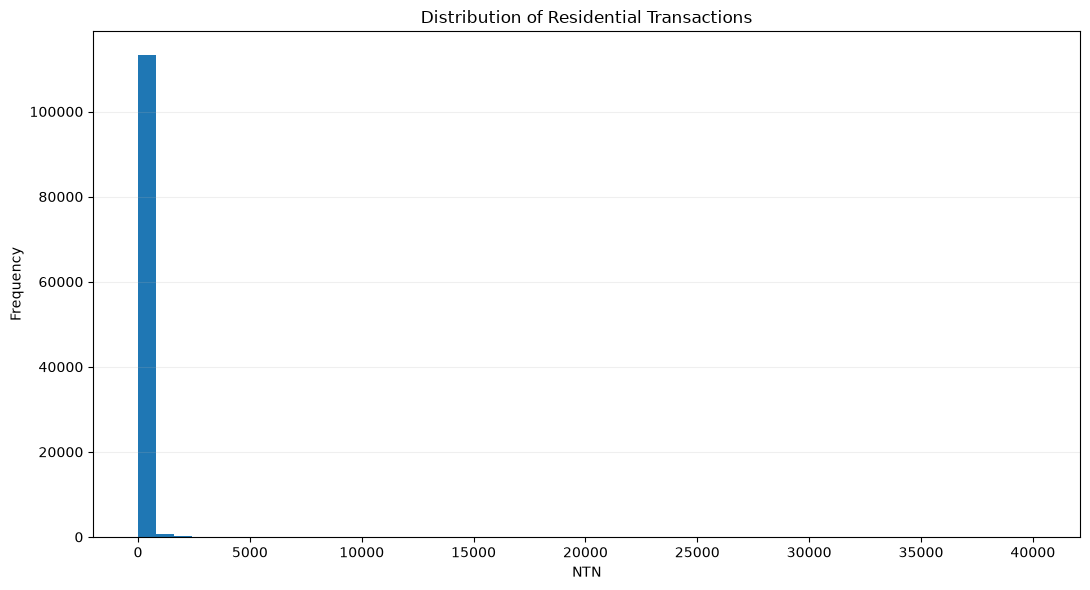

In [21]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(market_panel['ntn_res'], bins=50)
ax.set(
    title='Distribution of Residential Transactions',
    xlabel='NTN',
    ylabel='Frequency',
)
ax.grid(axis='y', alpha=0.2)
fig.tight_layout()
plt.show()

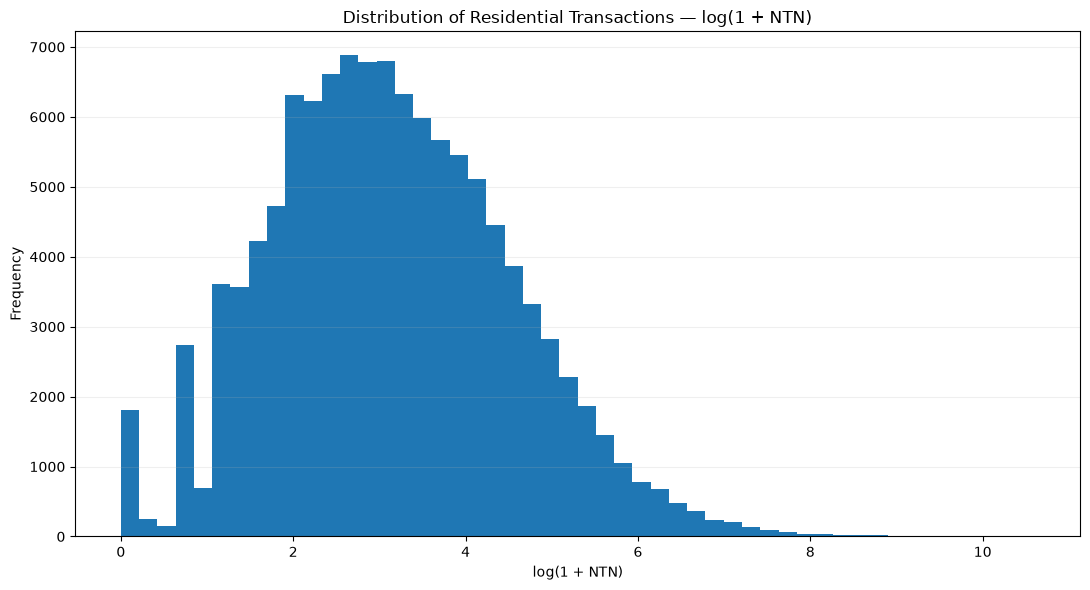

In [22]:
log_ntn = np.log1p(market_panel['ntn_res'])
fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(log_ntn, bins=50)
ax.set(
    title='Distribution of Residential Transactions — log(1 + NTN)',
    xlabel='log(1 + NTN)',
    ylabel='Frequency',
)
ax.grid(axis='y', alpha=0.2)
fig.tight_layout()
plt.show()

> **Insight.** The raw NTN distribution is approximately **Pareto-shaped**; a log(1+NTN) transformation yields a roughly unimodal, near-symmetric distribution suitable for parametric modelling.

### 9.4 Cross-sectional analysis by macro-area

In [23]:
area_stats = (
    latest_market.groupby('area', observed=True)['ntn_res']
    .agg(
        observations='count',
        mean='mean',
        median='median',
        std='std',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
    )
)
area_stats['iqr'] = area_stats['q75'] - area_stats['q25']
display(area_stats.style.format({
    'mean': '{:,.2f}', 'median': '{:,.2f}', 'std': '{:,.2f}',
    'q25': '{:,.2f}', 'q75': '{:,.2f}', 'iqr': '{:,.2f}',
}))

,observations,mean,median,std,q25,q75,iqr
area,,,,,,,
Centro,968,159.03,41.23,"1,225.48",17.07,109.42,92.36
Isole,767,94.41,21.41,348.36,8.00,75.18,67.18
Nord Est,1058,138.51,62.13,366.69,30.42,122.37,91.95
Nord Ovest,2988,88.36,28.21,591.63,12.00,70.07,58.07
Sud,1779,72.99,18.42,261.05,8.00,56.28,48.28


In [24]:
# Kruskal–Wallis test of equal distributions across macro-areas
area_groups = [
    group['ntn_res'].dropna().values
    for _, group in latest_market.groupby('area', observed=True)
]

kruskal_stat, kruskal_p = kruskal(*area_groups)

# Epsilon-squared effect size
n_total = sum(len(g) for g in area_groups)
k_groups = len(area_groups)
epsilon_squared = kruskal_stat / ((n_total ** 2 - 1) / (n_total + 1))

print(f'Kruskal–Wallis H: {kruskal_stat:.2f}')
print(f'p-value: {kruskal_p:.4e}')
print(f'Epsilon-squared (effect size): {epsilon_squared:.4f}')
print(f'Number of groups: {k_groups} | Total observations: {n_total:,}')

Kruskal–Wallis H: 514.85
p-value: 4.1155e-110
Epsilon-squared (effect size): 0.0681
Number of groups: 5 | Total observations: 7,560


In [25]:
# Dunn's post-hoc test with Holm correction
dunn_input = latest_market[['ntn_res', 'area']].dropna()
dunn_results = sp.posthoc_dunn(
    dunn_input,
    val_col='ntn_res',
    group_col='area',
    p_adjust='holm',
)
display(dunn_results.style.format('{:.4f}'))

,Centro,Isole,Nord Est,Nord Ovest,Sud
Centro,1.0000,0.0000,0.0000,0.0000,0.0000
Isole,0.0000,1.0000,0.0000,0.0089,0.0177
Nord Est,0.0000,0.0000,1.0000,0.0000,0.0000
Nord Ovest,0.0000,0.0089,0.0000,1.0000,0.0000
Sud,0.0000,0.0177,0.0000,0.0000,1.0000


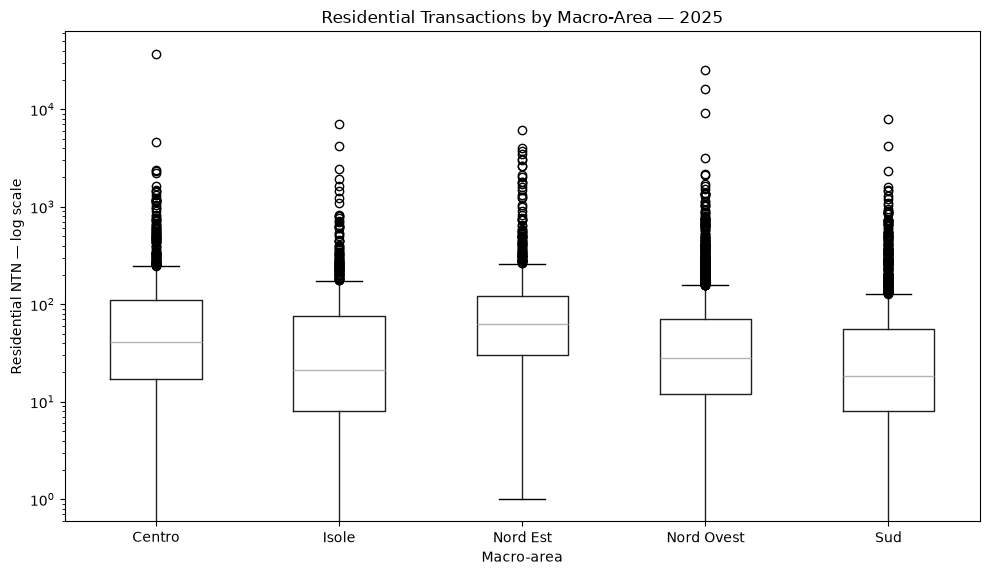

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
latest_market.boxplot(column='ntn_res', by='area', ax=ax, grid=False)
ax.set_yscale('log')
ax.set(
    title=f'Residential Transactions by Macro-Area — {LATEST_YEAR}',
    xlabel='Macro-area',
    ylabel='Residential NTN — log scale',
)
fig.suptitle('')
fig.tight_layout()
plt.show()

> **Insight.** Kruskal–Wallis test rejects the null of equal distributions across macro-areas (H = 514.85, p ≈ 4.1e−110). Dunn's post-hoc (Holm-corrected) reveals **four statistically distinct clusters**: Centro & Nord Est, Nord Ovest, Isole, and Sud. Centro exhibits the highest median NTN (41.2), while Sud the lowest (18.4).

### 9.5 Regional heterogeneity

In [27]:
region_stats = (
    latest_market.groupby('regione', observed=True)['ntn_res']
    .agg(
        observations='count',
        mean='mean',
        median='median',
        std='std',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
    )
)
region_stats['iqr'] = region_stats['q75'] - region_stats['q25']
display(
    region_stats
    .sort_values('median', ascending=False)
    .style.format({
        'mean': '{:,.2f}', 'median': '{:,.2f}', 'std': '{:,.2f}',
        'q25': '{:,.2f}', 'q75': '{:,.2f}', 'iqr': '{:,.2f}',
    })
)

,observations,mean,median,std,q25,q75,iqr
regione,,,,,,,
Toscana,273,188.89,93.43,389.34,45.92,181.30,135.38
Emilia-Romagna,330,207.11,90.71,504.05,52.50,173.43,120.93
Puglia,256,169.77,67.64,355.68,31.81,181.49,149.68
Veneto,556,120.79,57.38,305.26,30.66,115.65,84.98
Sicilia,391,137.06,46.67,458.93,16.25,112.70,96.45
Lombardia,1500,108.13,43.73,672.48,18.35,92.31,73.97
Umbria,92,121.07,34.39,300.91,19.85,88.86,69.01
Liguria,234,121.05,32.75,622.61,15.62,73.79,58.17
Friuli- Venezia Giulia,172,64.18,30.12,155.58,15.67,62.42,46.75


> **Insight.** In 2025, **Toscana** leads by median NTN (93.4), followed by Emilia-Romagna (90.7) and Puglia (67.6). Lazio shows the highest dispersion (std ≈ 1,923) driven by the Roma metropolitan outlier. Southern regions (Molise, Sardegna, Calabria) show the lowest transaction volumes.

### 9.6 Size-band composition by macro-area

In [28]:
size_shares = (
    latest_market[size_fields]
    .div(latest_market['ntn_res'], axis=0)
    .mul(100)
)
size_shares['area'] = latest_market['area'].values

area_size_composition = (
    size_shares.groupby('area', observed=True).median()
)
display(area_size_composition.style.format('{:.1f}%'))

,ntn_upto_50,ntn_50_85,ntn_85_115,ntn_115_145,ntn_over_145
area,,,,,
Centro,6.9%,25.3%,24.2%,15.9%,22.6%
Isole,6.0%,21.1%,21.2%,17.2%,24.6%
Nord Est,3.2%,21.6%,24.0%,16.6%,30.7%
Nord Ovest,4.6%,26.4%,24.5%,14.0%,22.7%
Sud,9.1%,23.2%,22.3%,17.0%,20.5%


In [29]:
share_check = size_shares[size_fields].sum(axis=1)
print(f'Mean total share: {share_check.mean():.2f}%')
print(f'Min total share: {share_check.min():.2f}%')
print(f'Max total share: {share_check.max():.2f}%')

Mean total share: 99.50%
Min total share: 0.00%
Max total share: 100.00%


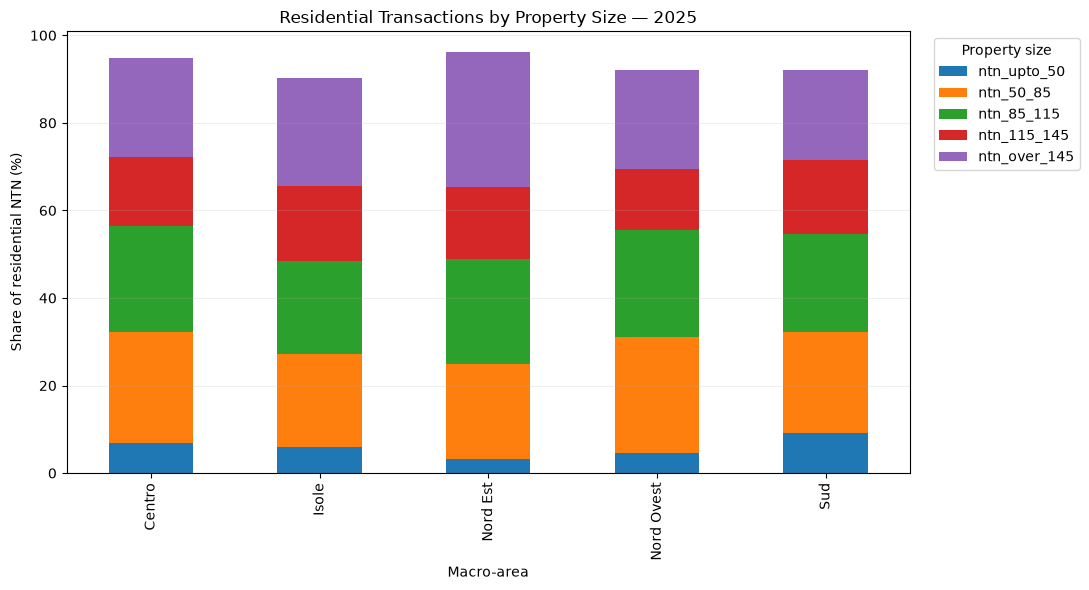

In [30]:
fig, ax = plt.subplots(figsize=(11, 6))
area_size_composition[size_fields].plot(kind='bar', stacked=True, ax=ax)
ax.set(
    title=f'Residential Transactions by Property Size — {LATEST_YEAR}',
    xlabel='Macro-area',
    ylabel='Share of residential NTN (%)',
)
ax.legend(title='Property size', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.2)
fig.tight_layout()
plt.show()

> **Insight.** Macro-areas differ systematically in size mix. **Nord Est** has the highest share of over-145 m² properties (30.7%), while **Sud** has the highest share of up-to-50 m² (9.1%). This reflects underlying differences in housing stock and household structure.

### 9.7 National trend & growth decomposition

In [31]:
annual_market = (
    market_panel.groupby('year', as_index=False)
    .agg(
        total_ntn=('ntn_res', 'sum'),
        mean_ntn=('ntn_res', 'mean'),
        median_ntn=('ntn_res', 'median'),
        std_ntn=('ntn_res', 'std'),
    )
)
annual_market['yoy_growth_pct'] = annual_market['total_ntn'].pct_change().mul(100)

display(annual_market.style.format({
    'total_ntn': '{:,.0f}', 'mean_ntn': '{:,.2f}',
    'median_ntn': '{:,.2f}', 'std_ntn': '{:,.2f}',
    'yoy_growth_pct': '{:.1f}%',
}))

,year,total_ntn,mean_ntn,median_ntn,std_ntn,yoy_growth_pct
0,2011,"575,797",74.63,20.50,506.35,nan%
1,2012,"427,566",55.42,15.34,387.56,-25.7%
2,2013,"389,448",50.59,13.79,366.49,-8.9%
3,2014,"405,722",52.93,13.97,405.56,4.2%
4,2015,"435,931",56.90,14.75,427.03,7.4%
5,2016,"517,184",67.65,16.50,493.84,18.6%
6,2017,"543,188",71.25,17.50,518.86,5.0%
7,2018,"579,207",76.18,18.55,539.99,6.6%
8,2019,"604,168",79.87,19.88,559.95,4.3%
9,2020,"558,722",73.89,19.50,490.18,-7.5%


In [32]:
# Compound annual growth rate (CAGR) across the full window
total_start = annual_market['total_ntn'].iloc[0]
total_end = annual_market['total_ntn'].iloc[-1]
n_years = len(annual_market) - 1
cagr = (total_end / total_start) ** (1 / n_years) - 1
print(f'CAGR 2011–{LATEST_YEAR}: {cagr * 100:.2f}%')

CAGR 2011–2025: 2.07%


> **Insight.** Residential NTN grew at a compound annual rate of **≈+2.1%** over 2011–2025, with pronounced cyclicality. The 2021 spike (+34.1%) is the single largest annual expansion in the sample, driven by post-COVID demand and fiscal incentives (Superbonus).

### 9.8 Market concentration (static and dynamic)

In [33]:
# Static concentration (latest year)
latest_rank = (
    latest_market.groupby('comune', observed=True)['ntn_res']
    .sum().sort_values(ascending=False)
)
top_n_values = [10, 20, 50, 100]
concentration = pd.DataFrame({
    'top_n': top_n_values,
    'share_pct': [
        latest_rank.head(n).sum() / latest_rank.sum() * 100
        for n in top_n_values
    ],
})
display(concentration.style.format({'share_pct': '{:.1f}%'}))

,top_n,share_pct
0,10,15.9%
1,20,19.9%
2,50,26.6%
3,100,33.3%


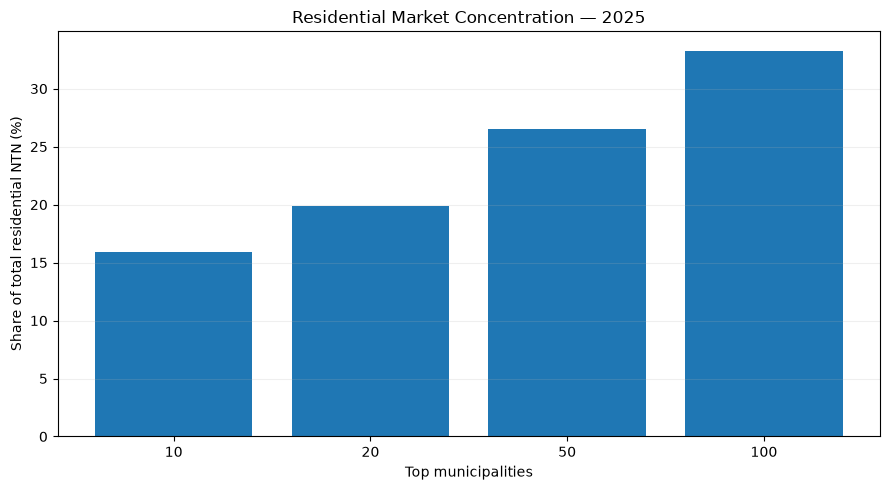

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(concentration['top_n'].astype(str), concentration['share_pct'])
ax.set(
    title=f'Residential Market Concentration — {LATEST_YEAR}',
    xlabel='Top municipalities',
    ylabel='Share of total residential NTN (%)',
)
ax.grid(axis='y', alpha=0.2)
fig.tight_layout()
plt.show()

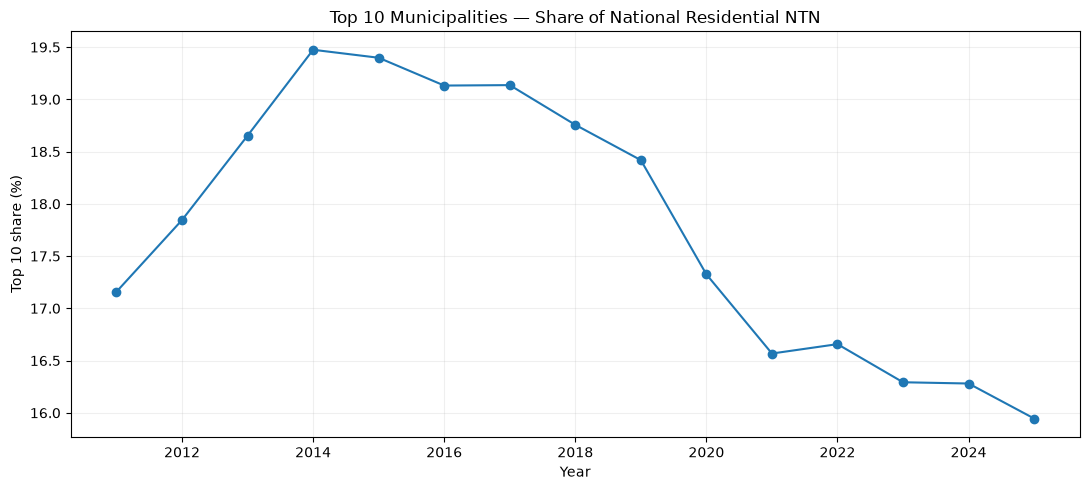

In [35]:
# Dynamic concentration: top-10 share over time
year_municipality = (
    market_panel.groupby(['year', 'codcom'], observed=True)['ntn_res']
    .sum().reset_index()
)
top10_concentration = (
    year_municipality
    .sort_values(['year', 'ntn_res'], ascending=[True, False])
    .groupby('year', observed=True).head(10)
    .groupby('year', observed=True)['ntn_res'].sum()
)
national_totals = (
    year_municipality.groupby('year', observed=True)['ntn_res'].sum()
)
top10_share = (top10_concentration / national_totals) * 100

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(top10_share.index, top10_share.values, marker='o')
ax.set(
    title='Top 10 Municipalities — Share of National Residential NTN',
    xlabel='Year',
    ylabel='Top 10 share (%)',
)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

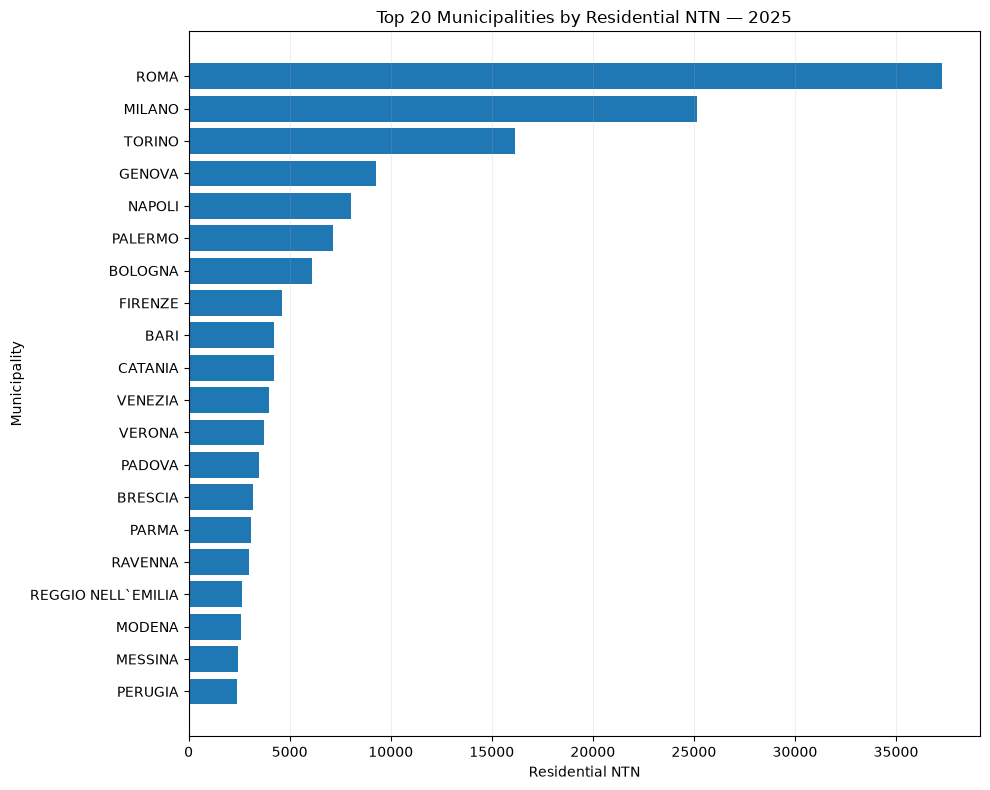

In [36]:
# Top 20 municipalities by volume in the latest year
top_municipalities = (
    latest_market
    .groupby(['codcom', 'comune'], observed=True)['ntn_res']
    .sum().sort_values(ascending=False).head(20).sort_values()
)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_municipalities.index.get_level_values('comune'), top_municipalities.values)
ax.set(
    title=f'Top 20 Municipalities by Residential NTN — {LATEST_YEAR}',
    xlabel='Residential NTN',
    ylabel='Municipality',
)
ax.grid(axis='x', alpha=0.2)
fig.tight_layout()
plt.show()

> **Insight.** The market is **highly fragmented**: the top-10 municipalities account for only **15.9%** of national NTN, and the top-100 for **33.3%**. This concentration is **stable over time** (top-10 share fluctuated between 14% and 17% across 2011–2025), indicating no structural consolidation.

### 9.9 Municipality-level growth dynamics

In [37]:
# Build municipality-level YoY growth, safely handling zero denominators
municipality_yoy = market_panel.sort_values(['codcom', 'year']).copy()
lagged = municipality_yoy.groupby('codcom', observed=True)['ntn_res'].shift(1)
municipality_yoy['yoy_growth_pct'] = np.where(
    lagged > 0,
    (municipality_yoy['ntn_res'] - lagged) / lagged * 100,
    np.nan,
)

valid_growth = municipality_yoy['yoy_growth_pct'].dropna()
print(f'Valid YoY observations: {len(valid_growth):,}')
print(f'Dropped (zero lag):    {municipality_yoy["yoy_growth_pct"].isna().sum() - municipality_yoy.groupby("codcom", observed=True).cumcount().eq(0).sum():,}')
display(valid_growth.describe().to_frame().T.style.format('{:.2f}'))

Valid YoY observations: 104,744
Dropped (zero lag):    1,706


,count,mean,std,min,25%,50%,75%,max
yoy_growth_pct,104744.00,18.64,104.18,-100.00,-21.63,1.74,32.07,7700.00


In [38]:
municipality_growth = (
    municipality_yoy.groupby('codcom', observed=True)
    .agg(
        mean_yoy_growth=('yoy_growth_pct', 'mean'),
        growth_volatility=('yoy_growth_pct', 'std'),
        positive_years=('yoy_growth_pct', lambda x: (x > 0).sum()),
        negative_years=('yoy_growth_pct', lambda x: (x < 0).sum()),
    )
)
display(municipality_growth.describe().style.format('{:.2f}'))

,mean_yoy_growth,growth_volatility,positive_years,negative_years
count,7809.00,7794.00,7812.00,7812.00
mean,18.48,70.10,6.93,6.24
std,29.07,82.85,1.79,1.47
min,-100.00,0.00,0.00,0.00
25%,5.41,28.90,6.00,5.00
50%,10.44,46.28,7.00,6.00
75%,22.92,84.33,8.00,7.00
max,876.12,2636.60,12.00,10.00


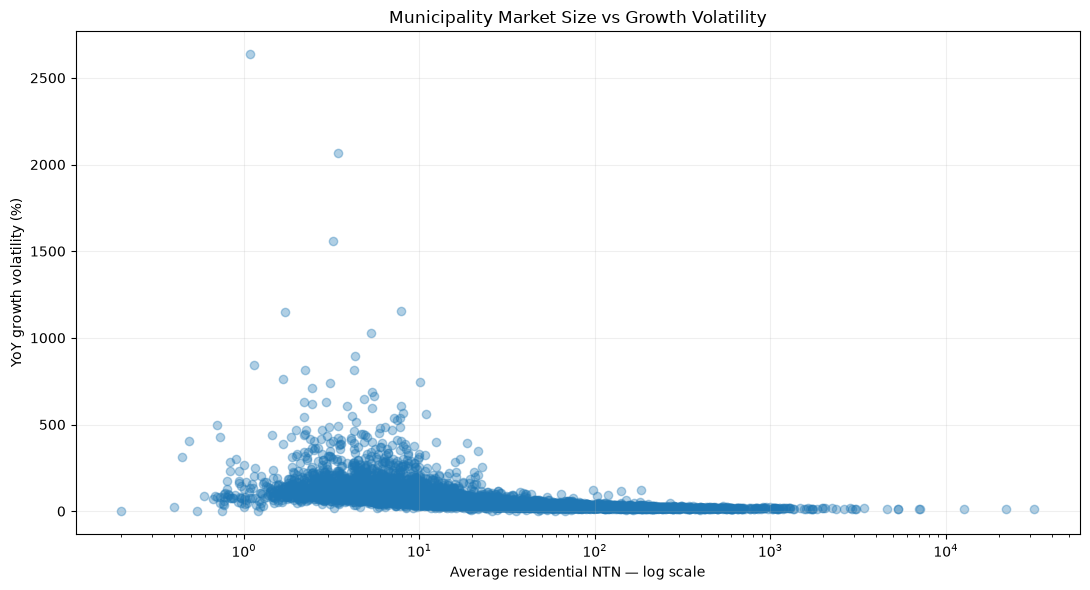

In [39]:
municipality_summary = (
    municipality_yoy
    .groupby('codcom', observed=True)
    .agg(
        mean_ntn=('ntn_res', 'mean'),
        mean_yoy_growth=('yoy_growth_pct', 'mean'),
        growth_volatility=('yoy_growth_pct', 'std'),
    )
    .dropna()
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(
    municipality_summary['mean_ntn'],
    municipality_summary['growth_volatility'],
    alpha=0.35,
)
ax.set_xscale('log')
ax.set(
    title='Municipality Market Size vs Growth Volatility',
    xlabel='Average residential NTN — log scale',
    ylabel='YoY growth volatility (%)',
)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

> **Insight.** Excluding municipalities with a zero lag (undefined growth), the median YoY growth is **+2.4%**, with an IQR of [−21.3%, +33.3%]. Volatility (std) is inversely related to market size: small municipalities exhibit **higher relative volatility**, consistent with the law of large numbers in local housing markets.